# Build Symbol Clasifier

## Prepare Data

In [1]:
import tensorflow as tf
import glob
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from pprint import pprint
import string
import os
import re

I0000 00:00:1780505804.345176    5536 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1780505805.562119    5536 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780505810.830631    5536 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
data_path = "content/my_dataset/model_3/*"

In [ ]:
!mkdir -p /content/my_dataset

In [ ]:
!unzip -q /content/drive/MyDrive/ml_datasets/captcha_decoder/dataset_for_3_models.zip -d /content/my_dataset

In [2]:
ALLOWED_CHARS = string.ascii_uppercase + string.digits
NUM_CLASSES = len(ALLOWED_CHARS)

CLASS_TO_INDEX = {char: idx for idx, char in enumerate(ALLOWED_CHARS)}
INDEX_TO_CLASS = {idx: char for char, idx in CLASS_TO_INDEX.items()}

pprint(CLASS_TO_INDEX)

{'0': 26,
 '1': 27,
 '2': 28,
 '3': 29,
 '4': 30,
 '5': 31,
 '6': 32,
 '7': 33,
 '8': 34,
 '9': 35,
 'A': 0,
 'B': 1,
 'C': 2,
 'D': 3,
 'E': 4,
 'F': 5,
 'G': 6,
 'H': 7,
 'I': 8,
 'J': 9,
 'K': 10,
 'L': 11,
 'M': 12,
 'N': 13,
 'O': 14,
 'P': 15,
 'Q': 16,
 'R': 17,
 'S': 18,
 'T': 19,
 'U': 20,
 'V': 21,
 'W': 22,
 'X': 23,
 'Y': 24,
 'Z': 25}


In [13]:
pattern = r"_([A-Za-z0-9])\.png$"
img_paths = list(glob.glob(data_path))

list_of_imgs = []
list_of_classes = []

for p in img_paths:
    clean_filename = os.path.basename(p)
    match = re.search(pattern, clean_filename)

    if not match:
        continue

    symbol = match.group(1)
    cls = CLASS_TO_INDEX.get(symbol)
    list_of_classes.append(cls)

    img = img_to_array(load_img(p, target_size=(52, 36), color_mode="grayscale"))
    list_of_imgs.append(img)


X = np.array(list_of_imgs, dtype=np.float32) / 255.0
Y = np.array(list_of_classes, dtype=np.float32)

In [14]:
X.shape, Y.shape

((13, 52, 36, 1), (13,))

In [19]:
X_train = X.copy()
X_train[X_train < 0.5] = 0.0
X_train[X_train >= 0.5] = 1.0

np.unique(X_train)

array([0., 1.], dtype=float32)

IDX: 3.0 Class: D


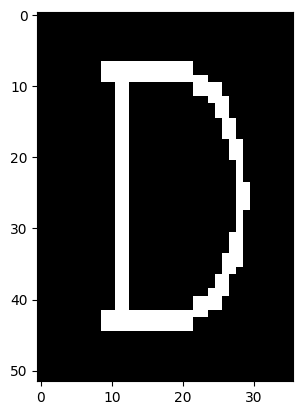

In [20]:
print("IDX:", Y[0], "Class:", INDEX_TO_CLASS[int(Y[0])])
plt.imshow(X_train[0], cmap="gray")

## Build Model

In [23]:
inp = tf.keras.layers.Input(shape=(52, 36, 1))

x = tf.keras.layers.Conv2D(32, kernel_size=3, activation='relu', padding='same')(inp)
x = tf.keras.layers.Conv2D(32, kernel_size=3, activation='relu', padding='same')(x)
x = tf.keras.layers.MaxPooling2D()(x) # 26x18

x = tf.keras.layers.Conv2D(64, kernel_size=3, activation='relu', padding='same')(x)
x = tf.keras.layers.Conv2D(64, kernel_size=3, activation='relu', padding='same')(x)
x = tf.keras.layers.MaxPooling2D()(x) # 13x9

x = tf.keras.layers.Conv2D(128, kernel_size=3, activation='relu', padding='same')(x)
x = tf.keras.layers.Conv2D(128, kernel_size=3, activation='relu', padding='same')(x)
x = tf.keras.layers.Conv2D(128, kernel_size=3, activation='relu', padding='same')(x)

x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(256, activation='relu')(x)
x = tf.keras.layers.Dropout(0.4)(x) 
x = tf.keras.layers.Dense(128, activation='relu')(x)
x = tf.keras.layers.Dropout(0.3)(x)

out = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')(x)

In [24]:
model = tf.keras.models.Model(inputs=inp, outputs=out)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 52, 36, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 52, 36, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 52, 36, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 18, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 26, 18, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 26, 18, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 13, 9, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 13, 9, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 13, 9, 128)     │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 13, 9, 128)     │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 14976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │     3,834,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 36)             │         4,644 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,305,668 (16.42 MB)

 Trainable params: 4,305,668 (16.42 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath="drive/MyDrive/ml_models/sym_clf/best_sym_clf_model.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

history = model.fit(
    X_train, Y,
    validation_split=0.1,
    epochs=30,
    batch_size=64,
    shuffle=True,
    callbacks=[early_stopping, checkpoint_callback] 
)

Epoch 1/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.0000e+00 - loss: 3.5957

W0000 00:00:1780504537.798231  249383 cpu_allocator_impl.cc:82] Allocation of 25878528 exceeds 10% of free system memory.
W0000 00:00:1780504537.854572  249382 cpu_allocator_impl.cc:82] Allocation of 23182848 exceeds 10% of free system memory.
W0000 00:00:1780504537.854916  249384 cpu_allocator_impl.cc:82] Allocation of 23182848 exceeds 10% of free system memory.
W0000 00:00:1780504537.880579  249381 cpu_allocator_impl.cc:82] Allocation of 28035072 exceeds 10% of free system memory.


1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step - accuracy: 0.0000e+00 - loss: 3.5957 - val_accuracy: 0.0000e+00 - val_loss: 3.6271
Epoch 2/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 508ms/step - accuracy: 0.0000e+00 - loss: 3.5768

W0000 00:00:1780504539.554611  249384 cpu_allocator_impl.cc:82] Allocation of 25878528 exceeds 10% of free system memory.


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 762ms/step - accuracy: 0.0000e+00 - loss: 3.5768 - val_accuracy: 0.0000e+00 - val_loss: 3.6207
Epoch 3/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 988ms/step - accuracy: 0.0909 - loss: 3.5063 - val_accuracy: 0.0000e+00 - val_loss: 3.8579
Epoch 4/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 973ms/step - accuracy: 0.1818 - loss: 3.2957 - val_accuracy: 0.0000e+00 - val_loss: 4.8447
Epoch 5/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 665ms/step - accuracy: 0.1818 - loss: 3.4699 - val_accuracy: 0.0000e+00 - val_loss: 4.2452
Epoch 6/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 647ms/step - accuracy: 0.0909 - loss: 3.3444 - val_accuracy: 0.0000e+00 - val_loss: 3.8929
Epoch 7/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 828ms/step - accuracy: 0.1818 - loss: 3.2860 - val_accuracy: 0.0000e+00 - val_loss: 3.7556


## Local Test

In [12]:
pattern = r"_([A-Za-z0-9])\.png$"


def preprocesing_img(img_path):
    clean_filename = os.path.basename(img_path)
    match = re.search(pattern, clean_filename)
    
    symbol = match.group(1)

    img = img_to_array(load_img(img_path, target_size=(52, 36), color_mode="grayscale")) / 255.0

    img_cpy = img.copy()
    img_cpy[img_cpy < 0.5] = 0.0
    img_cpy[img_cpy >= 0.5] = 1.0
    return img_cpy[np.newaxis, ...], symbol

In [4]:
model = tf.keras.models.load_model("models/sym_clf_model.keras")

E0000 00:00:1780506075.312608    5536 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
31
Predicted symbol: 5, Actual symbol: 5


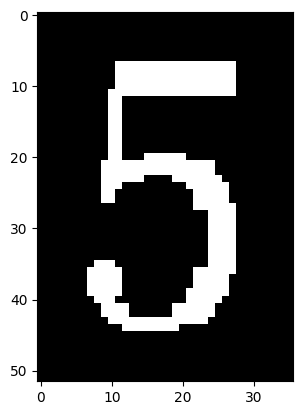

In [53]:
paths = glob.glob("../dataset/model_3/*")
idx = np.random.randint(0, len(paths) - 1)

img_path = paths[idx]
img, symbol = preprocesing_img(img_path)

y_pred = np.argmax(model.predict(img))
print(y_pred)
print(f"Predicted symbol: {INDEX_TO_CLASS[int(y_pred)]}, Actual symbol: {symbol}")
plt.imshow(img[0], cmap="gray")